In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ── Paths ───────────────────────────────────────────────────
RESULTS_DIR = "../results/metrics"
MODELS_DIR  = "../models"
FIGS_DIR    = "../results/figures"
os.makedirs(FIGS_DIR, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ── Load artifacts ──────────────────────────────────────────
with open(f"{RESULTS_DIR}/scaler_X.pkl", 'rb') as f: scaler_X = pickle.load(f)
with open(f"{RESULTS_DIR}/scaler_y.pkl", 'rb') as f: scaler_y = pickle.load(f)

df_all = pd.read_parquet(f"{RESULTS_DIR}/lab_cycles_labeled.parquet")

WINDOW       = 20
STRIDE       = 10
FEATURE_COLS = ['cap_Ah','v_mean','v_min','v_slope','i_mean',
                't_mean','t_max','energy_Wh','duration_min',
                'soc_start','soc_end','EFC_norm']
N_FEATURES   = len(FEATURE_COLS)

print(f"✅ Loaded | {len(df_all):,} cycles | {df_all['cell_id'].nunique()} cells")
print(f"  Splits: { {s: df_all[df_all['split']==s]['cell_id'].nunique() for s in ['train','val','test']} }")

✅ Loaded | 213,995 cycles | 206 cells
  Splits: {'train': 154, 'val': 26, 'test': 26}


In [2]:
class HyperPILSTM(nn.Module):
    """
    Physics-Informed LSTM with HyperNetwork-conditioned input projection.

    Key Innovation:
      A HyperNetwork (small MLP) takes EFC_norm (battery age 0→1) and
      generates a unique input projection matrix W_in [12×64] per sample.
      The LSTM literally uses different feature weights at each life stage:
        EFC_norm ≈ 0.1 → W focuses on v_slope, cap_Ah (SEI growth)
        EFC_norm ≈ 0.9 → W focuses on v_min, energy (knee point)

    Reference: Ha et al., HyperNetworks, ICLR 2017.
    """
    def __init__(self, input_size=12, hidden_size=64,
                 num_layers=2, dropout=0.4,
                 hyper_hidden=32, fc_dims=[32, 16]):
        super().__init__()
        self.input_size  = input_size
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── HyperNetwork: EFC_norm → W_in ───────────────────────────
        self.hypernet = nn.Sequential(
            nn.Linear(1, hyper_hidden),
            nn.ReLU(),
            nn.Linear(hyper_hidden, input_size * hidden_size)   # → [12×64]
        )

        # LayerNorm stabilises training (W values vary across ages)
        self.proj_norm = nn.LayerNorm(hidden_size)

        # Physics-informed warm-start (same as NB03)
        self.h0_embed = nn.Sequential(nn.Linear(1, hidden_size), nn.Tanh())

        # LSTM receives 64-dim projected features (not raw 12-dim)
        self.lstm = nn.LSTM(
            input_size  = hidden_size,      # ← 64 after projection
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = True
        )

        # RUL regression head
        layers, in_dim = [], hidden_size
        for out_dim in fc_dims:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        layers += [nn.Linear(in_dim, 1)]
        self.fc = nn.Sequential(*layers)

    def _project(self, x, efc_norm):
        """Age-conditioned input projection: [B,20,12] → [B,20,64]."""
        B = x.size(0)
        W = self.hypernet(efc_norm.unsqueeze(-1))               # [B, 768]
        W = W.view(B, self.input_size, self.hidden_size)        # [B, 12, 64]
        return self.proj_norm(torch.bmm(x, W))                  # [B, 20, 64]

    def get_embedding(self, x, efc_norm):
        """Returns h_T [B, 64] — used by NB07 for adversarial alignment."""
        x_proj = self._project(x, efc_norm)
        h0 = self.h0_embed(efc_norm.unsqueeze(-1))
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x_proj, (h0, c0))
        return out[:, -1, :]

    def forward(self, x, efc_norm):
        return self.fc(self.get_embedding(x, efc_norm)).squeeze(-1)

    def get_projection_weights(self, efc_norm_val):
        """Returns W_in [12, 64] for a given EFC_norm — for paper figure."""
        self.eval()
        with torch.no_grad():
            efcn = torch.tensor([[efc_norm_val]], dtype=torch.float32
                                ).to(next(self.parameters()).device)
            W = self.hypernet(efcn)
            return W.view(self.input_size, self.hidden_size).cpu().numpy()

    def get_feature_importance(self, efc_norm_val):
        """L2 norm of each W_in row = feature importance at given age."""
        W = self.get_projection_weights(efc_norm_val)
        return np.linalg.norm(W, axis=1)   # [12]


# ── Load pretrained weights ─────────────────────────────────
model = HyperPILSTM(input_size=12, hidden_size=64, num_layers=2,
                    dropout=0.4, hyper_hidden=32, fc_dims=[32, 16]).to(device)
model.load_state_dict(
    torch.load(f"{MODELS_DIR}/best_hyperpilstm.pt", map_location=device))
model.eval()

total_p = sum(p.numel() for p in model.parameters())
hyper_p = sum(p.numel() for p in model.hypernet.parameters())
print(f"✅ HyperPILSTM loaded | Total: {total_p:,} "
      f"(HyperNet: {hyper_p:,} → generates {12*64} weights per sample)")
print(f"   vs baseline PI-LSTM: 56,001 params (+{total_p-56001:,})")


# ── predict_cell helper ─────────────────────────────────────
def predict_cell(df_cell):
    """Run inference on a single cell, return EFC / true_RUL / pred_RUL arrays."""
    grp = df_cell.sort_values('EFC').reset_index(drop=True)
    X   = scaler_X.transform(grp[FEATURE_COLS].values)

    efcs, trues, preds = [], [], []
    for i in range(WINDOW, len(grp)):
        x_seq = torch.tensor(X[i-WINDOW:i],
                             dtype=torch.float32).unsqueeze(0).to(device)
        # ── FIX: extract per-cycle EFC_norm and pass to HyperPILSTM ──
        efcn  = torch.tensor([grp['EFC_norm'].iloc[i]],
                             dtype=torch.float32).to(device)
        with torch.no_grad():
            p = model(x_seq, efcn).item()               # ← was model(x_seq)
        efcs.append(grp['EFC'].iloc[i])
        trues.append(grp['RUL'].iloc[i])
        preds.append(np.clip(scaler_y.inverse_transform([[p]])[0][0], 0, 1))

    return np.array(efcs), np.array(trues), np.array(preds)

print("✅ predict_cell helper defined")

✅ HyperPILSTM loaded | Total: 94,849 (HyperNet: 25,408 → generates 768 weights per sample)
   vs baseline PI-LSTM: 56,001 params (+38,848)
✅ predict_cell helper defined


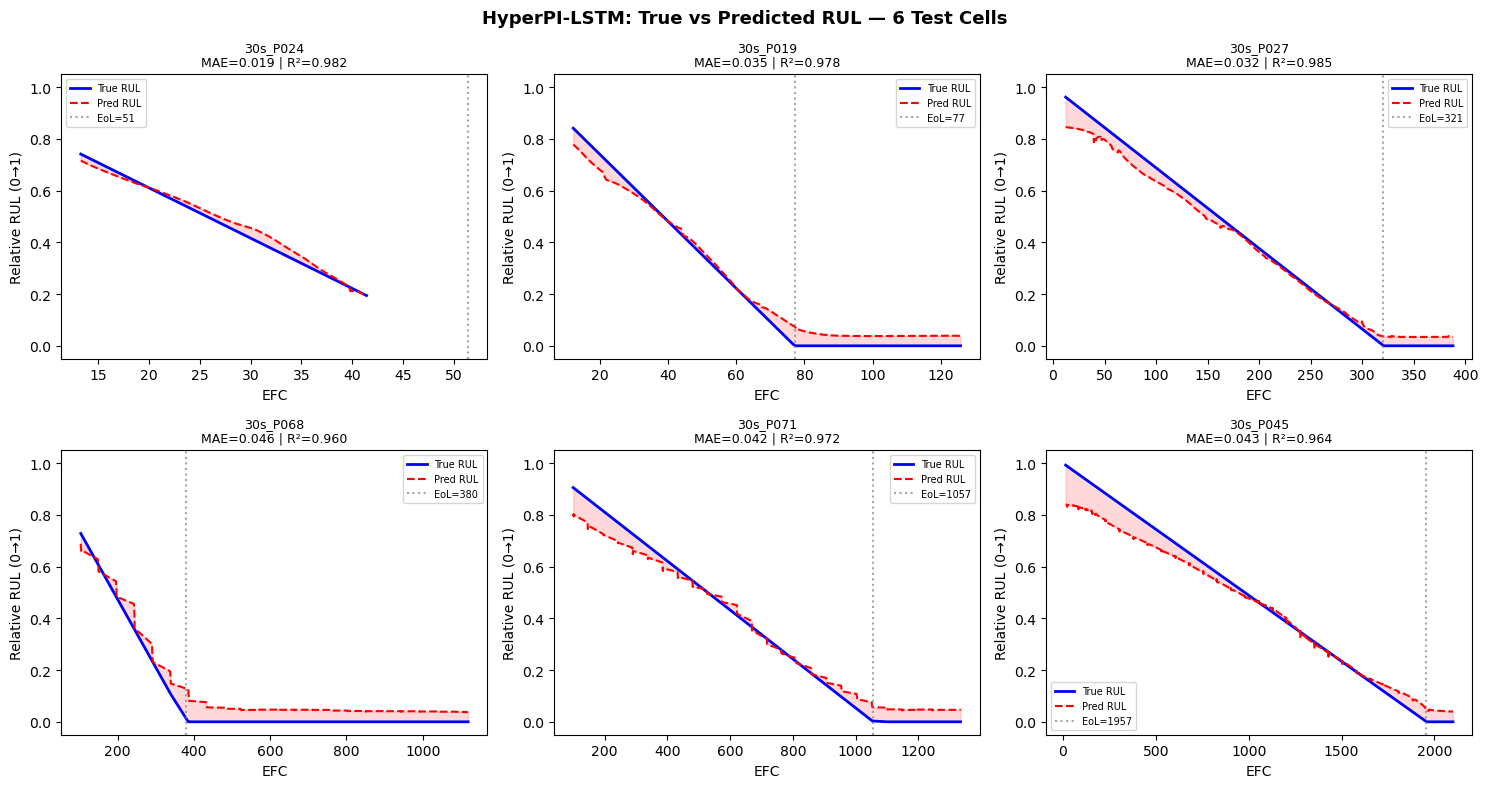

💾 Saved → results/figures/per_cell_rul_curves.png


In [3]:
test_cells = df_all[df_all['split']=='test']['cell_id'].unique()

# Pick 6 diverse cells — 2 short-lived, 2 medium, 2 long-lived
cell_eol  = df_all.groupby('cell_id')['EoL_EFC'].first()
test_eols = cell_eol[test_cells].sort_values()
picks     = list(test_eols.index[[0, 2,                    # short
                                   len(test_eols)//2 - 1,
                                   len(test_eols)//2,      # medium
                                   -3, -1]])               # long

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, cid in zip(axes, picks):
    efc, true_rul, pred_rul = predict_cell(df_all[df_all['cell_id']==cid])
    eol = cell_eol[cid]
    mae = mean_absolute_error(true_rul, pred_rul)
    r2  = r2_score(true_rul, pred_rul)

    ax.plot(efc, true_rul, 'b-',  linewidth=2,   label='True RUL')
    ax.plot(efc, pred_rul, 'r--', linewidth=1.5, label='Pred RUL')
    ax.fill_between(efc, true_rul, pred_rul, alpha=0.15, color='red')
    ax.axvline(eol, color='gray', linestyle=':', alpha=0.7, label=f'EoL={eol:.0f}')
    ax.set_title(f"{cid.split('_')[3]}_{cid.split('_')[4]}\n"
                 f"MAE={mae:.3f} | R²={r2:.3f}", fontsize=9)
    ax.set_xlabel('EFC');  ax.set_ylabel('Relative RUL (0→1)')
    ax.legend(fontsize=7); ax.set_ylim(-0.05, 1.05)

plt.suptitle('HyperPI-LSTM: True vs Predicted RUL — 6 Test Cells',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/per_cell_rul_curves.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/per_cell_rul_curves.png")

In [4]:
rows = []
for cid in test_cells:
    efc, true_rul, pred_rul = predict_cell(df_all[df_all['cell_id']==cid])
    for e, t, p in zip(efc, true_rul, pred_rul):
        rows.append({'cell_id': cid, 'EFC': e, 'true': t, 'pred': p})

pred_df = pd.DataFrame(rows)
pred_df['residual'] = pred_df['pred'] - pred_df['true']
pred_df['abs_err']  = pred_df['residual'].abs()

print(f"Total test predictions: {len(pred_df):,}")
print(f"\nOverall test metrics:")
print(f"  MAE  : {pred_df['abs_err'].mean():.4f}")
print(f"  RMSE : {np.sqrt((pred_df['residual']**2).mean()):.4f}")
print(f"  R²   : {r2_score(pred_df['true'], pred_df['pred']):.4f}")

Total test predictions: 23,153

Overall test metrics:
  MAE  : 0.0368
  RMSE : 0.0453
  R²   : 0.9804


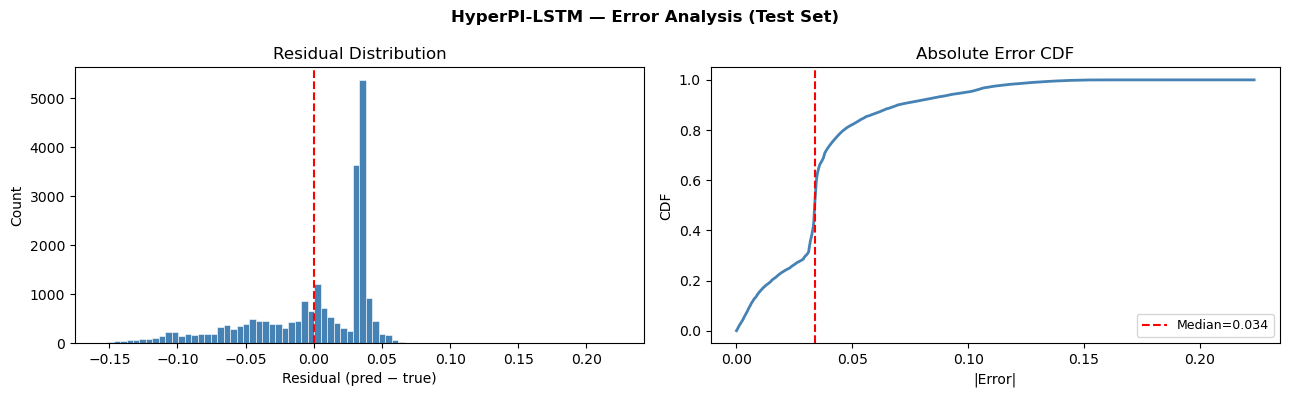

💾 Saved → results/figures/error_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: residual histogram
axes[0].hist(pred_df['residual'], bins=80, color='steelblue',
             edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (pred − true)'); axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution')

# Right: |error| CDF
sorted_err = np.sort(pred_df['abs_err'])
cdf        = np.arange(1, len(sorted_err)+1) / len(sorted_err)
axes[1].plot(sorted_err, cdf, color='steelblue', linewidth=2)
axes[1].axvline(pred_df['abs_err'].median(), color='red', linestyle='--',
                linewidth=1.5, label=f"Median={pred_df['abs_err'].median():.3f}")
axes[1].set_xlabel('|Error|'); axes[1].set_ylabel('CDF')
axes[1].set_title('Absolute Error CDF')
axes[1].legend(fontsize=9)

plt.suptitle('HyperPI-LSTM — Error Analysis (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/error_distribution.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/error_distribution.png")

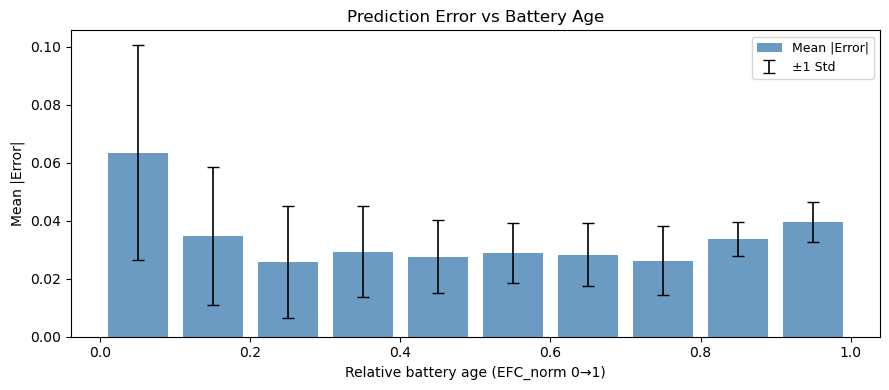

💾 Saved → results/figures/error_vs_age.png


In [6]:
pred_df['EFC_bin'] = pd.cut(pred_df['EFC'] / pred_df['EFC'].max(),
                            bins=10, labels=False)

age_err = pred_df.groupby('EFC_bin')['abs_err'].agg(['mean','std']).reset_index()
age_err['bin_center'] = (age_err['EFC_bin'] + 0.5) / 10

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(age_err['bin_center'], age_err['mean'], width=0.08,
       color='steelblue', alpha=0.8, label='Mean |Error|')
ax.errorbar(age_err['bin_center'], age_err['mean'],
            yerr=age_err['std'], fmt='none', color='black',
            capsize=4, linewidth=1.2, label='±1 Std')
ax.set_xlabel('Relative battery age (EFC_norm 0→1)')
ax.set_ylabel('Mean |Error|')
ax.set_title('Prediction Error vs Battery Age')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/error_vs_age.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/error_vs_age.png")

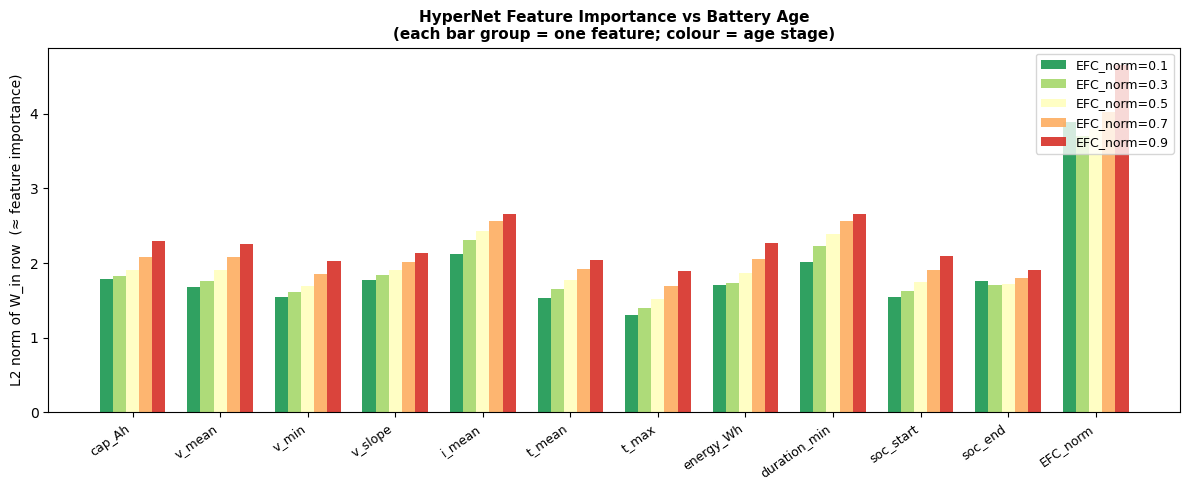

💾 Saved → results/figures/hypernet_feature_importance.png


In [7]:
ages  = [0.1, 0.3, 0.5, 0.7, 0.9]
color = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ages)))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(N_FEATURES)
bar_w = 0.15

for k, (age, c) in enumerate(zip(ages, color)):
    imp = model.get_feature_importance(age)
    ax.bar(x + k * bar_w, imp, width=bar_w, color=c,
           label=f'EFC_norm={age}', alpha=0.9)

ax.set_xticks(x + bar_w * 2)
ax.set_xticklabels(FEATURE_COLS, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('L2 norm of W_in row  (≈ feature importance)')
ax.set_title('HyperNet Feature Importance vs Battery Age\n'
             '(each bar group = one feature; colour = age stage)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f"{FIGS_DIR}/hypernet_feature_importance.png", dpi=150)
plt.show()
print("💾 Saved → results/figures/hypernet_feature_importance.png")